In [1]:
!pip install tensorflow

## **1.Importing Necessary files**

In [2]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from keras.datasets import mnist
from keras.datasets import fashion_mnist
from matplotlib import pyplot as plt
from keras.utils import to_categorical

2026-04-07 07:20:23.994086: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775546424.227141      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775546424.296525      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775546424.851165      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775546424.851219      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775546424.851223      17 computation_placer.cc:177] computation placer alr

## **2. Dataset Splitting**

In [3]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()
(A_train,A_test),(B_train,B_test)=fashion_mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [5]:
X_train.shape

(60000, 28, 28)

In [6]:
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

In [7]:
X_train.shape

(60000, 28, 28, 1)

In [8]:
X_test.shape

(10000, 28, 28, 1)

In [9]:
y_train.shape

(60000,)

In [10]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [11]:
y_train=to_categorical(y_train,num_classes=10)
y_test=to_categorical(y_test,num_classes=10)

In [12]:
y_train.shape

(60000, 10)

In [13]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [14]:
X_train=X_train/255
X_test=X_test/255

In [15]:
X_train[1]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

In [16]:
X_train.max()

np.float64(1.0)

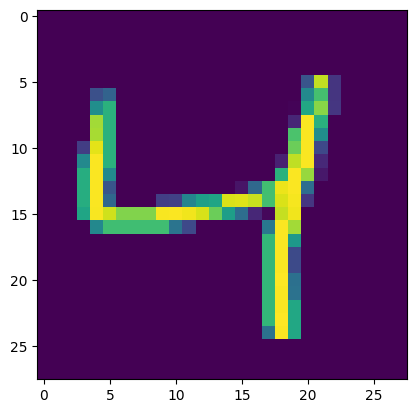

In [17]:
plt.imshow(X_train[2])

## **3.Standardizing the data**

In [18]:
X_train.shape

(60000, 28, 28, 1)

In [19]:
y_train.shape

(60000, 10)

## **4.Creating the model**

In [20]:
model=Sequential()
## Convolution Operation
model.add(Conv2D(32,kernel_size=(4,4),padding='valid',activation='relu',input_shape=(28,28,1)))
## padding = same then padding operation gets activated
## Pooling Operation
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
## padding =valid then padding operation is not activated

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(80,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-07 07:20:56.580323: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 80)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,098 (918.35 KB)

 Trainable params: 235,098 (918.35 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(loss='categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [23]:
history=model.fit(X_train,y_train,epochs=6,validation_data=(X_test,y_test))

Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.9071 - loss: 0.2922 - val_accuracy: 0.9828 - val_loss: 0.0484
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9854 - loss: 0.0459 - val_accuracy: 0.9890 - val_loss: 0.0351
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9910 - loss: 0.0280 - val_accuracy: 0.9904 - val_loss: 0.0291
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9933 - loss: 0.0215 - val_accuracy: 0.9904 - val_loss: 0.0306
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9950 - loss: 0.0158 - val_accuracy: 0.9907 - val_loss: 0.0311
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9959 - loss: 0.0123 - val_accuracy: 0.9913 - val_loss: 0.0316


In [24]:
y_pred=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [25]:
from sklearn.metrics import accuracy_score

In [26]:
y_pred

array([[5.09432015e-13, 7.08327491e-07, 3.20530482e-08, ...,
        9.99999106e-01, 1.24177990e-12, 3.61623584e-08],
       [1.22814562e-11, 3.25268630e-08, 9.99999940e-01, ...,
        3.19301287e-11, 1.03344606e-13, 5.67891437e-13],
       [2.89982314e-08, 9.99988973e-01, 3.31622317e-07, ...,
        7.90631293e-06, 9.18536955e-07, 4.05983286e-07],
       ...,
       [6.26710836e-12, 1.26716371e-09, 5.23655008e-10, ...,
        6.06173245e-08, 4.27717906e-09, 1.48106196e-07],
       [2.90204860e-09, 5.54231383e-10, 2.35487407e-14, ...,
        6.01733463e-12, 3.08210844e-07, 1.56364663e-08],
       [5.07313075e-07, 3.60519437e-09, 4.20523927e-09, ...,
        9.15301038e-13, 5.90775828e-09, 2.23522667e-09]], dtype=float32)

In [27]:
y_pred=y_pred.argmax(axis=1)

In [28]:
y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [29]:
import numpy as np
accuracy_score(np.argmax(y_test, axis=1), y_pred)

0.9913

In [30]:
np.argmax(y_test,axis=1)

array([7, 2, 1, ..., 4, 5, 6])

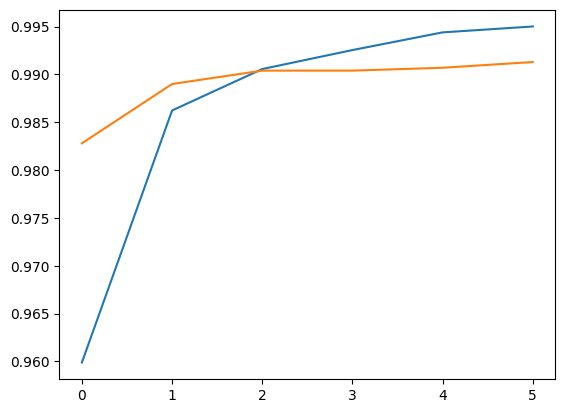

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

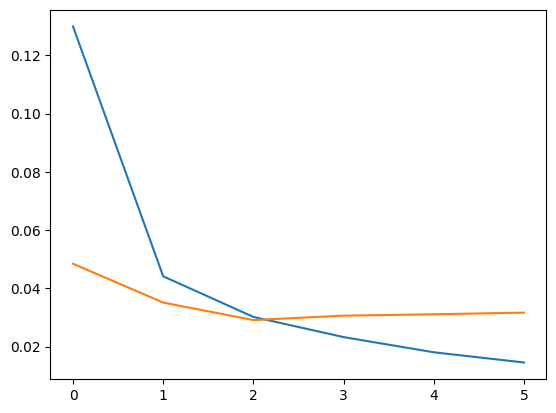

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])